
MDM, 9 JAN 2023  DVB 29 Aug. 2025

This is a sample analysis for the introductory lab on poisson statistics. It assumes that you have a .csv file uploaded (see "Files" at the left, you may need to click the folder icon). I labeled my runs
by two settings, the integration time (dt), and the SCA threshold (threshold). So the format of my table is:

<pre>
n,dt,threshold
2546,1,5
2567,1,5
2570,1,5
2600,1,5
</pre>

where n is the counts recorded. Students may choose to organize this differently, but then the separation of the data into different runs (~2 code cells below) would have to be adapted.

# Read in data and split into runs

I've grouped all my data into a single big file. Based on
the values in the data columns, I divide the data into "runs" based on the conditions I used to record the data. In my case, this was based on a threshold on the SCA and the integration time in LoggerPro.

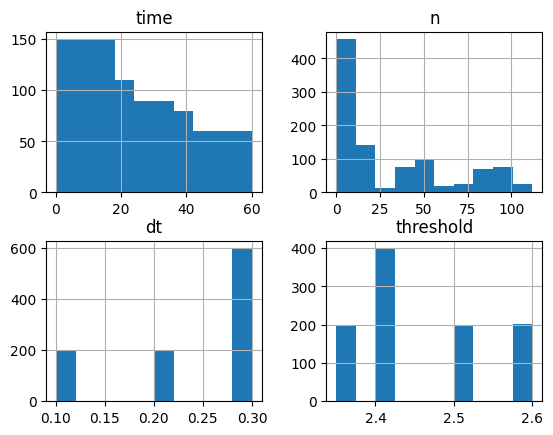

In [1]:
#
# Read in the data, and make a quick check that its there in the way I expect
#
import pandas as pd
df = pd.read_csv('data_file.csv')
df.hist() # Handy command to summarize what's in the file in plots
#
# I made five runs using different experimental conditions. Separate these out
# into their own data frames for futher analysis. Student may have organized
# their running differently and want to use different selections and/or
# variables.
#
run1 = df[(df["dt"]==0.2)   & (df["threshold"]==2)]
run2 = df[(df["dt"]==0.2)   & (df["threshold"]==2)]
run3 = df[(df["dt"]==0.2) & (df["threshold"]==2)]
run4 = df[(df["dt"]==0.2) & (df["threshold"]==2)]
run5 = df[(df["dt"]==0.2) & (df["threshold"]==2)]

# Make overlays of the poisson and gaussian distributions on my data


In [2]:
def make_overlays(title, df, nbins, nlo, nhi):
  ''' Prepare histograms and make overlays of poissons and gaussians whose
  parameters match the means and stdev's of the data.

  Parameters
  ----------
  title : string
    A name for this run of the experiment
  df : panda DataFrame
    The data from this run of the experiment
  nbins : int
    How maby bins to use for histogram
  nlo : float
    Low edge of histogram
  nhi : float
    High edge of histogram
  '''
  import numpy as np
  import matplotlib.pyplot as plt
  #
  # Make a histrogram of our results for the counts from the
  # various trials. We will plot this with sqrt(n) error bars on the
  # histogram bin contents.
  #
  n      = df['n']
  mean   = n.mean()
  stddev = n.std()
  ntrial = len(n)
  counts, bins = np.histogram(n, bins=np.linspace(nlo, nhi, nbins+1))
  sigma_counts = np.sqrt(counts)
  bin_centers  = 0.5*(bins[1:]+bins[:-1])
  plt.hist(bins[:-1], bins, weights=counts, color='lightblue')
  plt.errorbar(bin_centers, counts, yerr=sigma_counts, fmt='o', color='black', ecolor='black')
  #
  # Now plot the expected distribution for poisson distributed data
  # of the same mean as our data trials
  #
  import scipy.stats as stats
  #
  # We'll compute out to nhi rounded up to an integer
  #
  nx = int(nhi+1)
  x  = np.linspace(0,nx,nx+1)
  #
  # The normalization of the expected curve is a little tricky. Since the
  # poisson PDF is "per trial per count" we have to:
  #  - mulitply up by the number of trials we ran (len(df['n']))
  #  - multiply up by the width of the bins ((nhi-nlo)/nbins)
  # The formula for a poisson distribution is f(n) = exp(-mu)*mu^n/n!
  # As it happens this PDF is coded into scipy as poisson.pmf(...)
  # Same logic applies to the guassian ("normal") distribution.
  #
  norm = ntrial*(nhi-nlo)/nbins
  yp   = norm*stats.poisson.pmf(x, mean)
  yg   = norm*stats.norm.pdf(x,loc=mean,scale=stddev)
  plt.plot(x,yp,color='r',label='poisson')
  plt.plot(x,yg,color='b',label='gaussian')
  #
  # The rest is plot formatting
  #
  plt.xlabel('Counts')
  plt.ylabel('Number of trials / bin')
  plt.xlim([nlo,nhi])
  plt.grid(color='lightgrey')
  plt.legend()
  plt.title('%s : poisson and gaussian overlaid'%title)
  plt.savefig('%s-plot.pdf'%title, format="pdf", bbox_inches="tight")
  plt.show()

# Make fits to the poisson and gaussian distributions

To make fits to these distributions we need:

1. A $\chi^2$ function to compare the data and the model (gaussian or poisson)

2. Functions which return the Poisson or Gaussian predictions,
\begin{equation}
C(x) = A \frac{\mu^x e^{-x}}{x!} ~~~~~~~ [Poisson],
\end{equation}
\begin{equation}
C(x) = A \exp\left( {-\frac{(x-\mu)^2}{2 \sigma^2}} \right) ~~~~~~~[Gaussian]
\end{equation}
for the number of occurances $C$ as a function of the number of counts $x$ given a mean expectation of $\mu$, and a width of $\sigma$. NOTE: The Poisson formula depends onlly on A and $\mu$, the standard deviation and mean are coupled through the equation $\sigma = \sqrt{\mu}$. For both formulae, $A$ is a normalization constant proportional to the number of trials taken.

3. A way to find the model parameters ($A$, $\mu$, $\sigma$) that best-fit out data, minimizing $\chi^2$.

4. A way to estimate the uncertainties once the fit is complete. These are calculated based on the curvature of the $\chi^2$ at the minimum and calculating the excursion $\sigma_p$ required to increase the $\chi^2$ by one unit.

For example, the error on the parameter $\mu$ is estimated according to:
\begin{equation}
\chi^2 \simeq \chi^2_0 +
\frac{1}{2} \frac{ \partial^2 \chi^2 } {\partial \mu^2}
\sigma_\mu^2
\end{equation}
where the linear term in this Taylor series is $0$ by
construction since we are working at the $\chi^2$ minimum. Then:
\begin{equation}
\sigma_\mu =  \left( \frac{2}{\frac{ \partial^2 \chi^2 } {\partial \mu^2}} \right)^{\frac{1}{2}}
\end{equation}

In [3]:
import numpy as np
def chisqr(par, args):
  ''' A collection of chisqr functions which compare an observed number of
  counts, Nobs to a predicted number of counts Npred.

  Parameters:
  par : array of floats
    The parameters of the function whichs predicts observations
  args : array of mixed types:
    arg[0] : The model function of form Npred = func(x, par)
    arg[1] : The array of observed data counts Nobs in bins
    arg[2] : Array of x values as center of bins
    arg[3] : string options. Choose: gp, gm or p (see below)

  The functions implement different assumptions about the form of the chi^2.
  Options are:

  'gaussian' : Use the gaussian approximation for the variation in the
  histogram counts: [(Nobs-Npred)/sqrt(Npred)]^2

  'gaussian-o' : Use the gaussian approximation for the variation in the
  histogram counts, based on the observed counts: [(Nobs-Npred)/sqrt(Nobs)]^2

  'poisson' : Use the poisson form of chi^2 based on -2 log (L_poisson)

  See, eg. the Particle Data Group review on statistics:
  https://pdg.lbl.gov/2020/reviews/rpp2020-rev-statistics.pdf eqn. 40.16
  '''
  func  = args[0] # Which model function to call
  Nobs  = args[1] # The data we are comparing to
  xc    = args[2] # x values at center of bins
  opt   = args[3] # How to calculate the chi^2?
  Npred = func(xc, *par)

  if opt=='gaussian':
    delta = Nobs - Npred
    sigma = np.sqrt(Npred)
    chi2 = ((delta/sigma)**2).sum()
  elif opt=='gaussian-o':
    delta = Nobs - Npred
    sigma = np.sqrt(Nobs+1)
    chi2 = ((delta/sigma)**2).sum()
  elif opt=='poisson':
    tiny = 1e-12
    sum1 = Npred.sum()
    sum2 = Nobs.sum()
    sum3 = (Nobs*(np.log((Nobs+tiny)/(Npred+tiny)))).sum()
    chi2 = 2.0*(sum1-sum2+sum3)
  else:
    raise Exception('Please select gaussian, gaussian-o, or poisson')
  return chi2

def test_chisqrs():
  ''' A unit test of the chisqr functions above. As a test, take a linear model
  N = A + x*B with A = 1 and B = 2. Provide some fake data distributed around
  that model and be sure to include a zero bin as that is an important edge
  case the code should handle gracefully.
  '''
  def test_func(x, A, B):
    return A + x*B
  xc   = np.array([1, 2, 3,  4,  5])
  Nobs = np.array([0, 3, 7, 11, 12])
  arg1 = (test_func, Nobs, xc, 'gaussian')
  arg2 = (test_func, Nobs, xc, 'gaussian-o')
  arg3 = (test_func, Nobs, xc, 'poisson')
  par  = [1, 2]
  c1 = chisqr(par, arg1)
  c2 = chisqr(par, arg2)
  c3 = chisqr(par, arg3)
  print(c1, c2, c3)
# test_chisqrs()

In [4]:
import math
import scipy.stats as stats
#
# Our two models: the data is gaussian distributed or poisson distributed.
#
def gaussian_pdf(x, A, x0, sigma):
  return A*stats.norm.pdf(x,loc=x0,scale=sigma)
def poisson_pdf(x, A, mean):
  return A*stats.poisson.pmf(x, mean)

def make_fits(title, df, nbins, nlo, nhi, model_opt, chi2_opt):
  ''' Prepare histograms and make fits to poissons and gaussians
  Parameters
  ----------
  title : string
    A name for this run of the experiment
  df : panda DataFrame
    The data from this run of the experiment
  nbins : int
    How many bins to use for histogram
  nlo : float
    Low edge of histogram
  nhi : float
    High edge of histogram
  model_opt: string
    Which model to use for the data? Gaussian ('g') or poisson ('p')
  chi2_opt : string
    Which form of chi^2 to use? ('gn', 'gp', or 'p'). See chisqr(...)
  '''
  import numpy as np
  import matplotlib.pyplot as plt
  #
  # Make a histrogram of our results for the counts from the
  # various trials. Keep track of the bin center locations, xc.
  #
  Nobs, bins = np.histogram(df['n'], bins=np.linspace(nlo, nhi, nbins+1))
  xc         = np.round(0.5*(bins[1:]+bins[:-1]))
  #
  # Initialize the fit parameters switching between the gaussian model and
  # poisson
  #
  arg   = None
  names = None
  if model_opt=='gaussian':
    names = ['A','mean','sigma']
    x0 = np.array([0,0,0])
    x0[0] = Nobs.max()              # a guess at the normalization
    x0[1] = 0.5*(xc.max()+xc.min()) # a guess at the center
    x0[2] = 0.3*(xc.max()-xc.min()) # a guess at the width
    arg = [gaussian_pdf, Nobs, xc, chi2_opt]
  elif model_opt=='poisson':
    names = ['A','mean']
    x0 = np.array([0,0])
    x0[0] = Nobs.max()              # a guess at the normalization
    x0[1] = 0.5*(xc.max()+xc.min()) # a guess at the mean
    arg = [poisson_pdf,  Nobs, xc, chi2_opt]
  #
  # Run the minimizer. I'm using Nelder-Mead which may not be the fastest
  # minimizer out there, but it is very good at not getting lost.
  #
  from scipy.optimize import minimize
  result = minimize(chisqr, x0, arg, method='Nelder-Mead')
  #
  # Unpack and report results
  #
  chimin = result.fun
  x0     = result.x
  #
  # To compute the errors on x0 we look at the curvature of the chi^2 around
  # the minimum.
  #
  sigma  = np.empty(len(x0))
  x0up   = np.empty(len(x0))
  x0dn   = np.empty(len(x0))
  eps    = 0.1
  for i in range(0,len(x0)):
    x0up[:] = x0
    x0dn[:] = x0
    x0up[i] = x0up[i]+eps
    x0dn[i] = x0dn[i]-eps
    chiup = chisqr(x0up, arg)
    chidn = chisqr(x0dn, arg)
    #
    # Finite difference formula for 2nd derivative
    #
    curv = (chiup + chidn - 2.0*chimin)/eps/eps
    if curv==0.0:
      curv = 1e-9
    sigma[i] = math.sqrt(2.0/math.fabs(curv))
  print('** %s'%title)
  print(' Fit to %s PDF using %s errors on bins'%(model_opt, chi2_opt))
  print(' chi^2 = %f / %d DOF'%(chimin,np.count_nonzero(Nobs)-len(x0)))
  for i in range(len(x0)):
    print(' %s = %f +/- %f'%(names[i],x0[i],sigma[i]))
  return

# Process data

Define one function which runs each of the analysis tasks I want performed. Then step through each of my runs and run the analysis jobs.

In [5]:
#
# Since I'll want to do roughly the same analysis for each run, write that
# analysis once.
#
def proc_run(title, df, nbins, nlo, nhi):
  """ Perform analysis for a single run of the experiment
  Parameters
  ----------
  title : string
    A name for this run of the experiment
  df : panda DataFrame
    The data from this run of the experiment
  nbins : int
    How maby bins to use for histogram
  nlo : float
    Low edge of histogram
  nhi : float
    High edge of histogram
  """
  print('||*** Results for run \'%s\''%title)
  mean   = df['n'].mean()
  stddev = df['n'].std()
  ntrial = len(df['n'])
  print(' Mean    = %f'%mean)
  print(' StdDev  = %f'%stddev)
  print(' Ntrials = %d'%ntrial)
  #
  # Overlay the gaussian and poisson distributions of
  # the same mean and stddev as the data
  #
  make_overlays(title, df, nbins, nlo, nhi)
  #
  # Perform fits to gaussian and poisson letting the
  # normalizations, means, and sigma vary to fit
  # the data.
  #
  # When doing the fits we have two choices to make:
  # -- Which distribution to fit? poisson or gaussian
  # -- What to assume about the distribution of the bin contents?
  #    Are they gaussian or poisson distributed?
  #
  #
  PDF1    = 'poisson'
  PDF2    = 'gaussian'
  BINPDF1 = 'poisson'
  BINPDF2 = 'gaussian'
  make_fits(title, df, nbins, nlo, nhi, PDF1, BINPDF1)
  make_fits(title, df, nbins, nlo, nhi, PDF2, BINPDF1)
  make_fits(title, df, nbins, nlo, nhi, PDF1, BINPDF2)
  make_fits(title, df, nbins, nlo, nhi, PDF2, BINPDF2)

  print('==*** end report for run \'%s\'\n'%title)


||*** Results for run 'Run01'
 Mean    = 1.601990
 StdDev  = 6.144981
 Ntrials = 201


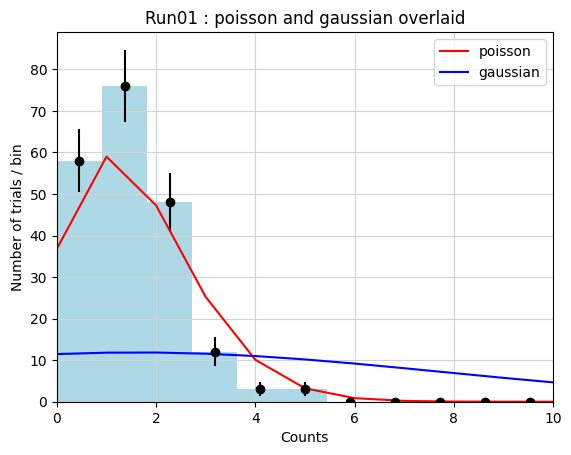

** Run01
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 5.953895 / 4 DOF
 A = 200.000036 +/- 14.142137
 mean = 1.175000 +/- 0.076510
** Run01
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 8.778882 / 3 DOF
 A = 246.169962 +/- 17.406844
 mean = 0.704540 +/- 0.117968
 sigma = 1.388723 +/- 0.080254
** Run01
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 6.016095 / 4 DOF
 A = 203.008084 +/- 14.248091
 mean = 1.215838 +/- 0.076431
** Run01
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 10.051454 / 3 DOF
 A = 265.715391 +/- 18.557203
 mean = 0.618320 +/- 0.127825
 sigma = 1.530596 +/- 0.071256
==*** end report for run 'Run01'

||*** Results for run 'Run02'
 Mean    = 2.690000
 StdDev  = 1.595817
 Ntrials = 200


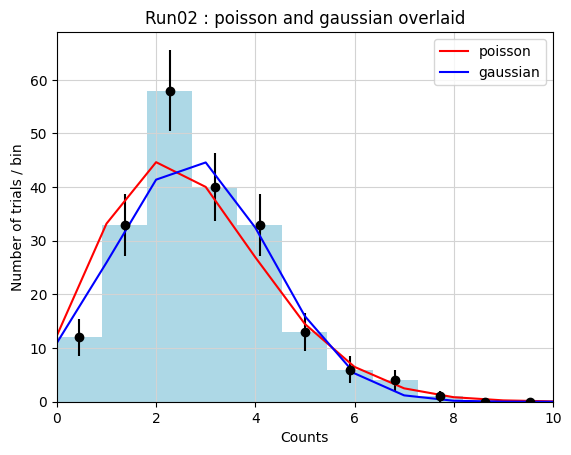

** Run02
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 4.792471 / 7 DOF
 A = 200.023417 +/- 14.143791
 mean = 2.691002 +/- 0.116136
** Run02
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 9.662253 / 6 DOF
 A = 208.059948 +/- 14.712059
 mean = 2.535659 +/- 0.134394
 sigma = 1.743453 +/- 0.105819
** Run02
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 4.498657 / 7 DOF
 A = 202.273955 +/- 14.223170
 mean = 2.703981 +/- 0.117946
** Run02
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 10.194332 / 6 DOF
 A = 214.490923 +/- 14.977146
 mean = 2.533096 +/- 0.137761
 sigma = 1.798840 +/- 0.090491
==*** end report for run 'Run02'

||*** Results for run 'Run03'
 Mean    = 13.790000
 StdDev  = 3.616809
 Ntrials = 200


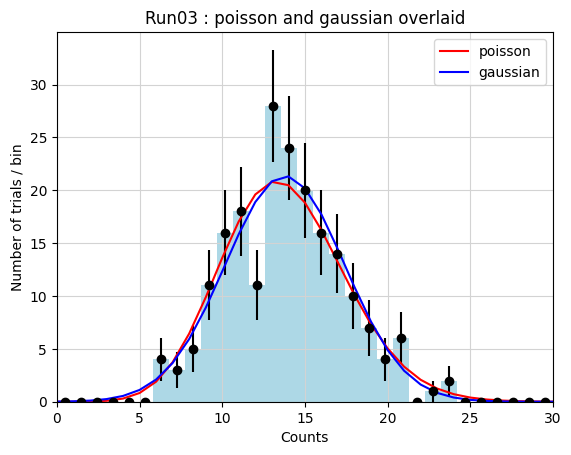

** Run03
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 21.888216 / 16 DOF
 A = 200.009127 +/- 14.142780
 mean = 13.790821 +/- 0.262722
** Run03
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 23.782217 / 15 DOF
 A = 200.007433 +/- 14.142660
 mean = 13.789488 +/- 0.255269
 sigma = 3.608904 +/- 0.180786
** Run03
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 17.999105 / 16 DOF
 A = 209.009790 +/- 14.457523
 mean = 13.842875 +/- 0.251220
** Run03
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 20.341649 / 15 DOF
 A = 210.192535 +/- 14.498768
 mean = 13.832798 +/- 0.265955
 sigma = 3.853262 +/- 0.183293
==*** end report for run 'Run03'

||*** Results for run 'Run04'
 Mean    = 45.500000
 StdDev  = 6.828848
 Ntrials = 200


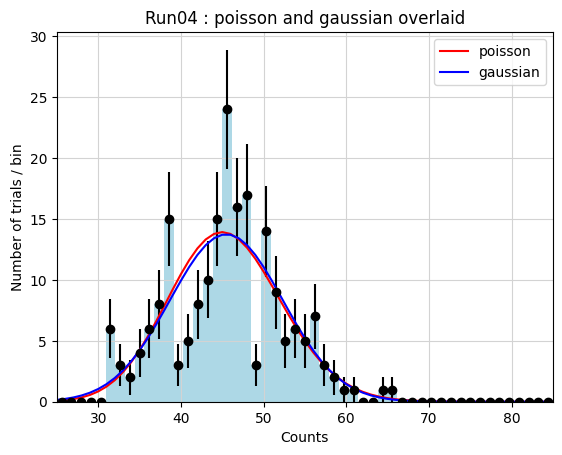

** Run04
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 59.624352 / 26 DOF
 A = 234.866971 +/- 16.607602
 mean = 45.569480 +/- 0.480605
** Run04
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 59.048047 / 25 DOF
 A = 235.121310 +/- 16.625586
 mean = 45.551584 +/- 0.491013
 sigma = 6.867704 +/- 0.354617
** Run04
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 57.935550 / 26 DOF
 A = 268.901824 +/- 17.770783
 mean = 45.211492 +/- 0.403903
** Run04
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 53.011120 / 25 DOF
 A = 266.894236 +/- 17.733715
 mean = 45.239428 +/- 0.500747
 sigma = 7.412797 +/- 0.349729
==*** end report for run 'Run04'

||*** Results for run 'Run05'
 Mean    = 89.713568
 StdDev  = 9.864402
 Ntrials = 199


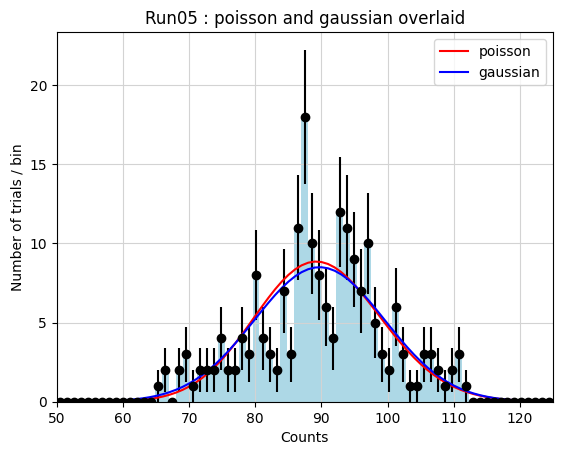

** Run05
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 63.738910 / 42 DOF
 A = 210.446374 +/- 14.918147
 mean = 89.722748 +/- 0.670876
** Run05
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 61.574099 / 41 DOF
 A = 210.357967 +/- 14.911880
 mean = 89.719086 +/- 0.698704
 sigma = 9.854308 +/- 0.501316
** Run05
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 64.806394 / 42 DOF
 A = 244.731710 +/- 16.088127
 mean = 89.395736 +/- 0.547015
** Run05
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 56.716765 / 41 DOF
 A = 240.372567 +/- 15.941506
 mean = 89.649336 +/- 0.697207
 sigma = 10.490195 +/- 0.492407
==*** end report for run 'Run05'



In [9]:
#
# Run my analysis on each data set. Since the counts change depending on the
# conditions, I shift the binning of the histograms around to match. Be careful
# with the binning at low counts to ensure that there is at least one counting
# number in every bin (and preferably only one!)
#
#        TITLE    DATA  NBINS LO EDGE HI EDGE
#        =======  ====  ===== ======= =======
proc_run('Run01', run1, 11,   0,   10)
proc_run('Run02', run2, 11,   0,    10)
proc_run('Run03', run3, 31,   0,    30)
proc_run('Run04', run4, 101,  0,   100)
proc_run('Run05', run5, 51,  50,    100)